In [41]:
# Step 1:Imports
import numpy as np
import yaml
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt
from scipy.stats import shapiro
import batman


In [42]:
# Step 2:Define HOPS folder
hops_folder = "/Users/danielbhuglah/Library/CloudStorage/OneDrive-TheOpenUniversity/SXS841 OSO Observations/2026_02_24_files_consolidated/PHOTOMETRY_41/PHOTOMETRY_APERTURE_FITTING"


In [43]:
# Step 3:Load detrended_mode.txt
detrended_path = f"{hops_folder}/detrended_model.txt"
data = np.loadtxt(detrended_path)

t          = data[:, 0]  # BJD_TDB
phase      = data[:, 1]
y          = data[:, 2]
yerr       = data[:, 3]
hops_model = data[:, 4]
hops_resid = data[:, 5]

# Normalise and flatten
y    = (y / np.median(y)).astype(float).flatten()
t    = t.astype(float).flatten()
yerr = yerr.astype(float).flatten()

print("Shapes:", t.shape, y.shape, yerr.shape)


Shapes: (124,) (124,) (124,)


In [44]:
# Step 4: Load log.yaml (initial parameters)
log_path = f"{hops_folder}/log.yaml"
with open(log_path, "r") as f:
    log_data = yaml.safe_load(f)

def log_get(key):
    return log_data[key]


In [45]:
# Step 5: Load results.txt (fitted values + uncertainties)
def parse_hops_results(path):
    params = {}
    with open(path) as f:
        for line in f:
            if line.startswith("#") or line.strip() == "":
                continue

            parts = line.split()
            if len(parts) < 3:
                continue

            name   = parts[0]
            fixfit = parts[1]
            value  = float(parts[2])

            if parts[3] == "--":
                unc_low  = None
                unc_high = None
            else:
                unc_low  = float(parts[3])
                unc_high = float(parts[4])

            params[name] = {
                "fixfit":  fixfit,
                "value":   value,
                "unc_low": unc_low,
                "unc_high": unc_high,
            }

    return params

results_path = f"{hops_folder}/results.txt"
hops = parse_hops_results(results_path)



In [46]:
# Step 6: Helper for uncertainties
def get_sigma(name):
    low  = hops[name]["unc_low"]
    high = hops[name]["unc_high"]
    if low is None or high is None:
        return 1e-6  # fixed parameter
    return (abs(low) + abs(high)) / 2

In [47]:
# Step 7: Phase‑fold the time array 
t0_hops = log_get("mid_time")
t_model = (t - t0_hops).flatten()

In [48]:
# Step8: Build exoplanet model (using log.yaml + results.txt)
# with pm.Model() as model:
# 
#     # Priors from HOPS
#     period = pm.Normal("period", mu=log_get("period"), sigma=1e-6)
#     t0     = pm.Normal("t0",     mu=0.0, sigma=get_sigma("mid_time"))
#     rp_rs  = pm.Normal("rp_rs",  mu=log_get("rp_over_rs"), sigma=get_sigma("rp_over_rs"))
#     a_rs   = pm.Normal("a_rs",   mu=log_get("sma_over_rs"), sigma=1e-6)
# 
#     # Impact parameter from inclination
#     inc_rad = np.radians(log_get("inclination"))
#     b_val   = log_get("sma_over_rs") * np.cos(inc_rad)
#     b       = pm.Normal("b", mu=b_val, sigma=0.05)
# 
#     # Limb darkening
#     u = xo.distributions.QuadLimbDark("u", testval=[0.3, 0.2])

    # Orbit
#     orbit = xo.orbits.KeplerianOrbit(
#         period=period,
#         t0=t0,
#         b=b,
#         a=a_rs,
#         ecc=0.0,
#         omega=0.0
#     )

    # --- ARM-SAFE LIGHT CURVE ENGINE ---
    # Disable all internal indexing paths that trigger broadcasting bugs
#     light_curve = xo.LimbDarkLightCurve(u)
# 
#     lc_model = light_curve.get_light_curve(
#         orbit=orbit,
#         r=rp_rs,
#         t=t_model,
#         texp=0.0,        # disables convolution path
#         oversample=1     # disables supersampling path
#     )

    # Extract 1-D vector
#     lc_model = pm.Deterministic("lc_model", lc_model[..., 0])

    # Likelihood
#     pm.Normal("obs", mu=lc_model, sigma=yerr, observed=y)

   

In [49]:
from pytensor.graph.op import Op

class BatmanOp(Op):
    itypes = [pt.dvector, pt.dscalar, pt.dscalar, pt.dscalar, pt.dscalar, pt.dscalar]
    otypes = [pt.dvector]

    def perform(self, node, inputs, outputs):
        t, period, t0, rp_rs, a_rs, inc = inputs

        params = batman.TransitParams()
        params.t0 = t0
        params.per = period
        params.rp = rp_rs
        params.a = a_rs
        params.inc = inc
        params.ecc = 0.0
        params.w = 90.0
        params.u = [0.3, 0.2]
        params.limb_dark = "quadratic"

        m = batman.TransitModel(params, t)
        flux = m.light_curve(params)

        outputs[0][0] = flux



In [50]:
batman_op = BatmanOp()

with pm.Model() as model:

    period = pm.Normal("period", mu=log_get("period"), sigma=1e-6)
    t0     = pm.Normal("t0",     mu=0.0, sigma=get_sigma("mid_time"))
    rp_rs  = pm.Normal("rp_rs",  mu=log_get("rp_over_rs"), sigma=get_sigma("rp_over_rs"))
    a_rs   = pm.Normal("a_rs",   mu=log_get("sma_over_rs"), sigma=1e-6)
    inc    = pm.Normal("inc",    mu=log_get("inclination"), sigma=0.5)
    m = batman.TransitModel(params, t, exp_time=log_get("exposure_time"))

    t_tensor = pt.as_tensor_variable(t_model)

    lc_model = pm.Deterministic("lc_model",batman_op(t_tensor, period, t0, rp_rs, a_rs, inc)
)
    period
    pm.Normal("obs", mu=lc_model, sigma=yerr, observed=y)


In [51]:
# Step 10: Sample posterior
# Step 10: Sample posterior with a gradient-free sampler
with model:
    step = pm.Metropolis()   # or pm.Slice(), both don't need grads
    trace = pm.sample(
        draws=2000,
        tune=2000,
        step=step,
        chains=4,
        cores=1,
        progressbar=True
    )


Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [period]
>Metropolis: [t0]
>Metropolis: [rp_rs]
>Metropolis: [a_rs]
>Metropolis: [inc]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 3 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [52]:
trace.posterior


<xarray.Dataset> Size: 8MB
Dimensions:         (chain: 4, draw: 2000, lc_model_dim_0: 124)
Coordinates:
  * chain           (chain) int64 32B 0 1 2 3
  * draw            (draw) int64 16kB 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
  * lc_model_dim_0  (lc_model_dim_0) int64 992B 0 1 2 3 4 ... 120 121 122 123
Data variables:
    period          (chain, draw) float64 64kB 18.8 18.8 18.8 ... 18.8 18.8 18.8
    t0              (chain, draw) float64 64kB 0.002139 0.002139 ... -0.0003616
    rp_rs           (chain, draw) float64 64kB 0.04224 0.03461 ... 0.03332
    a_rs            (chain, draw) float64 64kB 53.0 53.0 53.0 ... 53.0 53.0 53.0
    inc             (chain, draw) float64 64kB 89.2 89.15 89.15 ... 89.11 89.11
    lc_model        (chain, draw, lc_model_dim_0) float64 8MB 1.0 1.0 ... 1.0
Attributes:
    created_at:                 2026-06-17T18:26:53.721469+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.5
    sampling_time:              3.1457388401031494
    tuning_steps:               2000

In [58]:
# Step 9: Goodness of fit metrics
lc_fit = trace.posterior["lc_model"].mean(("chain", "draw")).values
residuals = y - lc_fit

chisq = np.sum((residuals / yerr)**2)
dof = len(y) 
reduced_chisq = chisq / dof

W, p = shapiro(residuals)
rms = np.std(residuals)

rp_mcmc = np.median(trace.posterior["rp_rs"].values)
depth = rp_mcmc**2
snr = depth / rms

chisq,reduced_chisq, W, p, rms, snr
print("Chi-squared:", chisq)
print("Degrees of freedom:", dof)
print("Reduced chi-squared:", reduced_chisq)
print("Shapiro W:", W)
print("Shapiro p:", p)
print("rms:", rms)
print("snr:", snr)
print("residuals",resid)

Chi-squared: 137.67638059696094
Degrees of freedom: 124
Reduced chi-squared: 1.1102933919109754
Shapiro W: 0.9845655722517421
Shapiro p: 0.17104679827939817
rms: 0.0032965958820536283
snr: 0.38096795907264824
residuals [-3.59013179e-03  3.86553833e-03  2.92646073e-04 -3.03923395e-03
  1.20181806e-03 -1.91041702e-04 -2.16957296e-03 -1.87794346e-03
 -2.85512063e-03 -8.32441102e-04 -3.70779987e-03  2.54375388e-03
  4.18902800e-03  2.80145899e-03  2.56662734e-03 -2.23062282e-03
  5.41040887e-03  6.52861224e-03  1.09793833e-02  5.62978637e-03
  1.19300521e-03 -1.42764869e-03  6.09088466e-03  2.46391919e-03
  8.12543353e-03  2.53211723e-03 -5.97421285e-03  3.84494706e-03
  6.55247827e-03  1.75939292e-03 -4.69833765e-04  6.22924430e-04
  6.71515742e-03  5.22314514e-04 -1.45637515e-03  6.34749286e-03
  1.81942137e-03  2.34743892e-03  3.49671488e-03 -2.69238535e-03
 -2.49460152e-03 -2.06608842e-03 -3.54578299e-03  2.86933735e-04
  2.20163300e-04 -1.76745119e-03  4.79911978e-03  9.99284205e-04
 

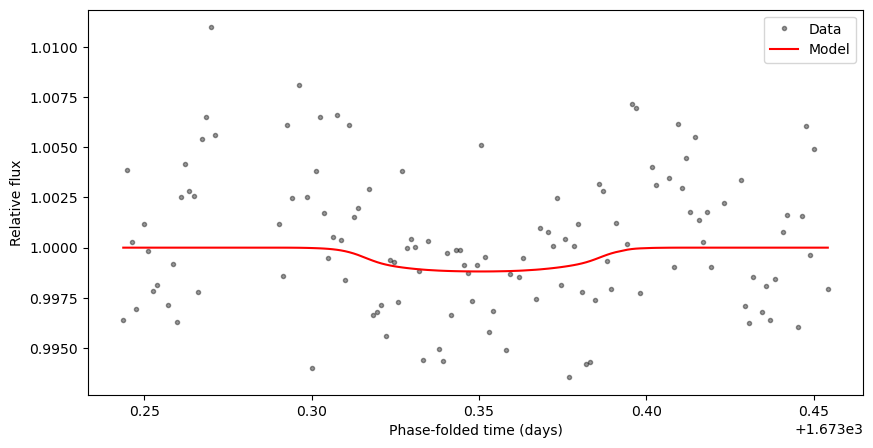

In [54]:
plt.figure(figsize=(10,5))
plt.plot(t_model, y, "k.", alpha=0.4, label="Data")
plt.plot(t_model, lc_fit, "r-", label="Model")
plt.xlabel("Phase-folded time (days)")
plt.ylabel("Relative flux")
plt.legend()
plt.show()


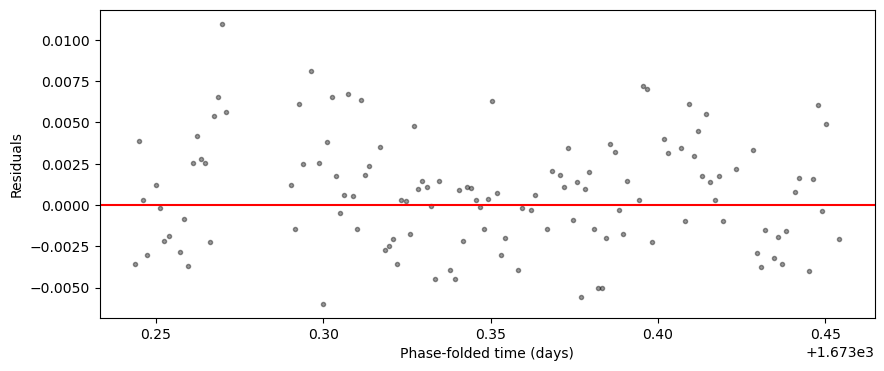

In [55]:
plt.figure(figsize=(10,4))
plt.plot(t_model, residuals, "k.", alpha=0.4)
plt.axhline(0, color="red")
plt.xlabel("Phase-folded time (days)")
plt.ylabel("Residuals")
plt.show()